---
title: Equilibrium Climate Sensitivity from CMIP6
author: Harsha R. Hampapura
tags:
  - origin:aws
  - platform:aws-ec2
  - dataset:cmip6
  - task:ecs
  - level:advanced
---
# Access CMIP6 zarr data from AWS using the osdf protocol and compute Equilibrium Climate Sensitivity (ECS)

[<span class="tag tag-origin">origin:aws</span>](/tag-index#tag-origin-aws) [<span class="tag tag-platform">platform:aws-ec2</span>](/tag-index#tag-platform-aws-ec2) [<span class="tag tag-dataset">dataset:cmip6</span>](/tag-index#tag-dataset-cmip6) [<span class="tag tag-task">task:ecs</span>](/tag-index#tag-task-ecs) [<span class="tag tag-level">level:advanced</span>](/tag-index#tag-level-advanced)

## Section 1: Introduction
- Load python packages
- Load catalog url

In [1]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import progress
from tqdm.autonotebook import tqdm
import intake
import fsspec
import seaborn as sns
import re
import aiohttp
import pandas as pd


/tmp/ipykernel_1805/3451259092.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
# import fsspec.implementations.http as fshttp
from pelicanfs.core import OSDFFileSystem,PelicanMap 

In [3]:
import os
# Local scratch on the EC2 instance (replaces the Casper /lustre path)
scratch_dir = os.path.expanduser("~/scratch")
os.makedirs(scratch_dir, exist_ok=True)
#
osdf_catalog       = 'https://data.gdex.ucar.edu/d850001/catalogs/cmip6-osdf-zarr.json'


## Section 2: Select Dask Cluster

In [4]:
#Create a LocalCluster using this EC2 instance's own CPU/RAM
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(local_directory=scratch_dir)   # auto-sizes to the instance
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 62.10 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34621,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43343,Total threads: 4
Dashboard: http://127.0.0.1:40759/status,Memory: 15.52 GiB
Nanny: tcp://127.0.0.1:45697,


In [5]:
# Scale the cluster and display cluster dashboard URL
n_workers =6
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

LocalCluster(205b9e33, 'tcp://127.0.0.1:34621', workers=6, threads=24, memory=93.14 GiB)

## Section 3: Data Loading
- Load catalog and select data subset

In [6]:
col = intake.open_esm_datastore(osdf_catalog)
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,709
grid_label,10
zstore,522217
dcpp_init_year,61


In [7]:
[eid for eid in col.df['experiment_id'].unique() if 'ssp' in eid]

['esm-ssp585-ssp126Lu',
 'ssp126-ssp370Lu',
 'ssp370-ssp126Lu',
 'ssp585',
 'ssp245',
 'ssp370-lowNTCF',
 'ssp370SST-ssp126Lu',
 'ssp370SST',
 'ssp370pdSST',
 'ssp370SST-lowCH4',
 'ssp370SST-lowNTCF',
 'ssp126',
 'ssp119',
 'ssp370',
 'esm-ssp585',
 'ssp245-nat',
 'ssp245-GHG',
 'ssp460',
 'ssp434',
 'ssp534-over',
 'ssp245-aer',
 'ssp245-stratO3',
 'ssp245-cov-fossil',
 'ssp245-cov-modgreen',
 'ssp245-cov-strgreen',
 'ssp245-covid',
 'ssp585-bgc']

In [8]:
query = dict(
    experiment_id=['abrupt-4xCO2','piControl'], # pick the `abrupt-4xCO2` and `piControl` forcing experiments
    table_id='Amon',                            # choose to look at atmospheric variables (A) saved at monthly resolution (mon)
    variable_id=['tas', 'rsut','rsdt','rlut'],  # choose to look at near-surface air temperature (tas) as our variable
    member_id = 'r1i1p1f1',                     # arbitrarily pick one realization for each model (i.e. just one set of initial conditions)
)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
ACCESS-CM2,2,4,1
ACCESS-ESM1-5,2,4,1
AWI-CM-1-1-MR,2,4,1
BCC-CSM2-MR,2,4,1
BCC-ESM1,2,4,1
CAMS-CSM1-0,2,4,1
CAS-ESM2-0,2,4,1
CESM2,2,4,1
CESM2-FV2,2,4,1


In [9]:
def drop_all_bounds(ds):
    """Drop coordinates like 'time_bounds' from datasets,
    which can lead to issues when merging."""
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop_vars(drop_vars)

def open_dsets(df):
    """Open datasets from cloud storage and return an xarray dataset."""
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    dsets = [xr.open_zarr(fsspec.get_mapper(ds_url), consolidated=True,
                          zarr_format=2, decode_times=time_coder)
             .pipe(drop_all_bounds)
             for ds_url in df.zstore]
    try:
        return xr.merge(dsets, join='exact')
    except ValueError:
        return None

def open_delayed(df):
    """A dask.delayed wrapper around `open_dsets`.
    Allows us to open many datasets in parallel."""
    return dask.delayed(open_dsets)(df)

In [10]:
from collections import defaultdict

dsets = defaultdict(dict)
for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

In [12]:
dsets_ = dask.compute(dict(dsets))[0]

## Section 4: Data Analysis
- Reduce data via Global Mean


In [13]:
def get_lat_name(ds):
    """Figure out what is the latitude coordinate for each dataset."""
    for lat_name in ['lat', 'latitude']:
        if lat_name in ds.coords:
            return lat_name
    raise RuntimeError("Couldn't find a latitude coordinate")

def global_mean(ds):
    """Return global mean of a whole dataset."""
    lat = ds[get_lat_name(ds)]
    weight = np.cos(np.deg2rad(lat))
    weight /= weight.mean()
    other_dims = set(ds.dims) - {'time'}
    return (ds * weight).mean(other_dims)

In [14]:
expts = ['piControl', 'abrupt-4xCO2']
expt_da = xr.DataArray(expts, dims='experiment_id',
                       coords={'experiment_id': expts})

dsets_aligned = {}

for k, v in tqdm(dsets_.items()):
    expt_dsets = v.values()
    if any([d is None for d in expt_dsets]):
        print(f"Missing experiment for {k}")
        continue

    for ds in expt_dsets:
        ds.coords['year'] = ds.time.dt.year - ds.time.dt.year[0]

    # workaround for
    # https://github.com/pydata/xarray/issues/2237#issuecomment-620961663
    dsets_ann_mean = [v[expt].pipe(global_mean).swap_dims({'time': 'year'}).drop_vars('time').coarsen(year=12).mean()
                      for expt in expts]

    # align everything with the 4xCO2 experiment
    dsets_aligned[k] = xr.concat(dsets_ann_mean, join='right',dim=expt_da)

  7%|██████▌                                                                                  | 3/41 [00:01<00:16,  2.37it/s]

Missing experiment for ACCESS-ESM1-5


 22%|███████████████████▌                                                                     | 9/41 [00:03<00:07,  4.18it/s]

Missing experiment for CAS-ESM2-0


 44%|██████████████████████████████████████▋                                                 | 18/41 [00:04<00:03,  6.10it/s]

...

 54%|███████████████████████████████████████████████▏                                        | 22/41 [00:05<00:02,  6.74it/s]

Missing experiment for FIO-ESM-2-0
Missing experiment for GFDL-CM4


 83%|████████████████████████████████████████████████████████████████████████▉               | 34/41 [00:08<00:01,  5.94it/s]

Missing experiment for MPI-ESM-1-2-HAM


100%|████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:10<00:00,  4.08it/s]


In [15]:
%%time
dsets_aligned_ = dask.compute(dsets_aligned)[0]

CPU times: user 20.1 s, sys: 2.41 s, total: 22.5 s
Wall time: 3min 27s


In [16]:
source_ids = list(dsets_aligned_.keys())
source_da = xr.DataArray(source_ids, dims='source_id',coords={'source_id': source_ids})

big_ds = xr.concat([ds.reset_coords(drop=True) for ds in dsets_aligned_.values()],
                   dim=source_da)
big_ds

/tmp/ipykernel_1805/4208675474.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  big_ds = xr.concat([ds.reset_coords(drop=True) for ds in dsets_aligned_.values()],


<xarray.Dataset> Size: 2MB
Dimensions:        (source_id: 35, experiment_id: 2, year: 999)
Coordinates:
  * source_id      (source_id) <U17 2kB 'ACCESS-CM2' ... 'TaiESM1'
  * experiment_id  (experiment_id) <U12 96B 'piControl' 'abrupt-4xCO2'
  * year           (year) float64 8kB 0.0 1.0 2.0 3.0 ... 996.0 997.0 998.0
Data variables:
    rlut           (source_id, experiment_id, year) float64 559kB 242.2 ... nan
    tas            (source_id, experiment_id, year) float64 559kB 287.0 ... nan
    rsut           (source_id, experiment_id, year) float64 559kB 97.84 ... nan
    rsdt           (source_id, experiment_id, year) float64 559kB 340.4 ... nan
Attributes: (12/53)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  346615.0
    cmor_version:           3.4.0
    ...                     ...
    version:                v20191112
    axis:                   Y
    bounds:                 lat_bnds
    long_name:              Latitude
    standard_name:          latitude
    units:                  degrees_north

### Calculated Derived Variables

In [17]:
big_ds['imbalance'] = big_ds['rsdt'] - big_ds['rsut'] - big_ds['rlut']

ds_mean = big_ds[['tas', 'imbalance']].sel(experiment_id='piControl').mean(dim='year')
ds_anom = big_ds[['tas', 'imbalance']] - ds_mean

# add some metadata
ds_anom.tas.attrs['long_name'] = 'Global Mean Surface Temp Anom'
ds_anom.tas.attrs['units'] = 'K'
ds_anom.imbalance.attrs['long_name'] = 'Global Mean Radiative Imbalance'
ds_anom.imbalance.attrs['units'] = 'W m$^{-2}$'

ds_anom

<xarray.Dataset> Size: 1MB
Dimensions:        (year: 999, experiment_id: 2, source_id: 35)
Coordinates:
  * year           (year) float64 8kB 0.0 1.0 2.0 3.0 ... 996.0 997.0 998.0
  * experiment_id  (experiment_id) <U12 96B 'piControl' 'abrupt-4xCO2'
  * source_id      (source_id) <U17 2kB 'ACCESS-CM2' ... 'TaiESM1'
Data variables:
    tas            (source_id, experiment_id, year) float64 559kB -0.03737 .....
    imbalance      (source_id, experiment_id, year) float64 559kB -0.04809 .....
Attributes: (12/53)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  346615.0
    cmor_version:           3.4.0
    ...                     ...
    version:                v20191112
    axis:                   Y
    bounds:                 lat_bnds
    long_name:              Latitude
    standard_name:          latitude
    units:                  degrees_north

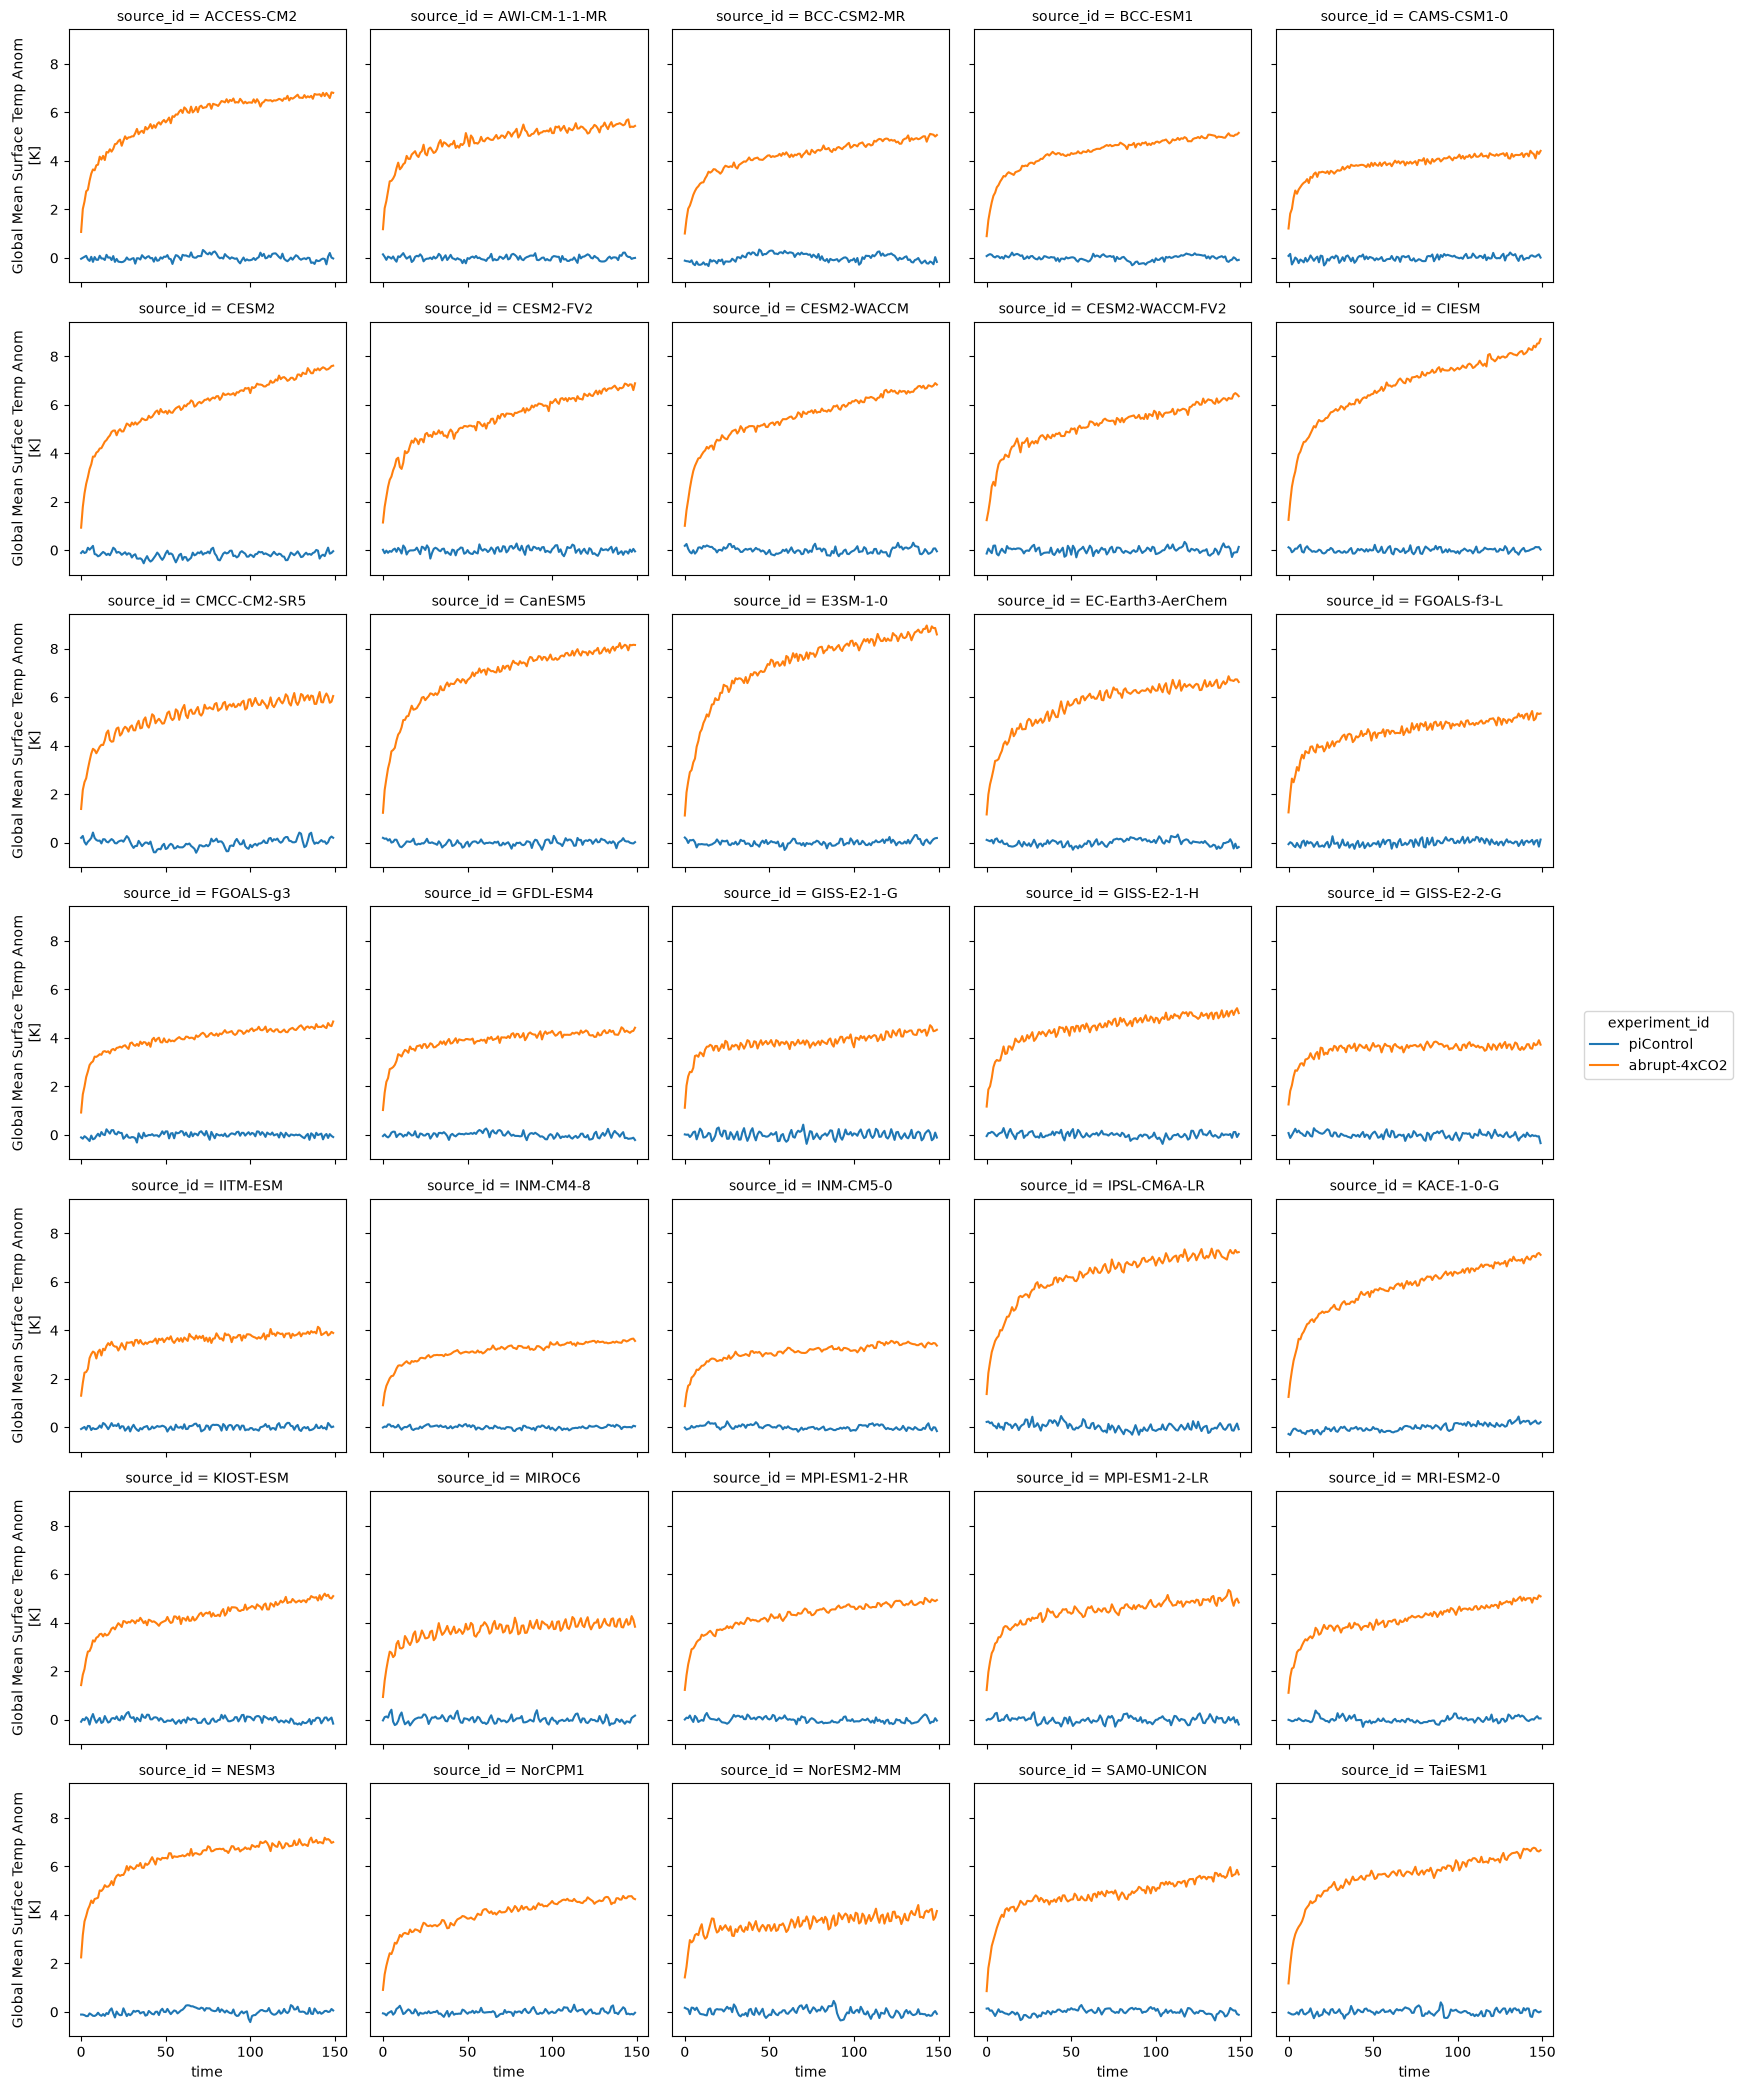

In [18]:
# limit to the gregory 150-year period
first_150_years = slice(0, 149)
ds_anom.tas.sel(year=first_150_years).plot.line(col='source_id', x='year', col_wrap=5)

### Calculate ECS

In [19]:
ds_abrupt = ds_anom.sel(year=first_150_years, experiment_id='abrupt-4xCO2').reset_coords(drop=True)

In [20]:
def calc_ecs(ds):
    tas_1d = ds.tas.squeeze()
    imbalance_1d = ds.imbalance.squeeze()

    # Align and drop NaNs
    tas_1d, imbalance_1d = xr.align(tas_1d.dropna('year'), imbalance_1d.dropna('year'), join='inner')

    a, b = np.polyfit(tas_1d.values, imbalance_1d.values, 1)
    ecs = -0.5 * (b / a)
    return xr.DataArray(ecs, attrs={'units': 'K'})

In [21]:
ds_abrupt['ecs'] = ds_abrupt.groupby('source_id').map(calc_ecs)
ds_abrupt

<xarray.Dataset> Size: 88kB
Dimensions:    (year: 150, source_id: 35)
Coordinates:
  * year       (year) float64 1kB 0.0 1.0 2.0 3.0 ... 146.0 147.0 148.0 149.0
  * source_id  (source_id) <U17 2kB 'ACCESS-CM2' 'AWI-CM-1-1-MR' ... 'TaiESM1'
Data variables:
    tas        (source_id, year) float64 42kB 1.071 2.014 2.323 ... 6.619 6.673
    imbalance  (source_id, year) float64 42kB 7.382 6.014 5.277 ... 2.143 2.141
    ecs        (source_id) float64 280B 4.728 3.124 3.021 ... 2.445 3.678 4.35
Attributes: (12/53)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  346615.0
    cmor_version:           3.4.0
    ...                     ...
    version:                v20191112
    axis:                   Y
    bounds:                 lat_bnds
    long_name:              Latitude
    standard_name:          latitude
    units:                  degrees_north

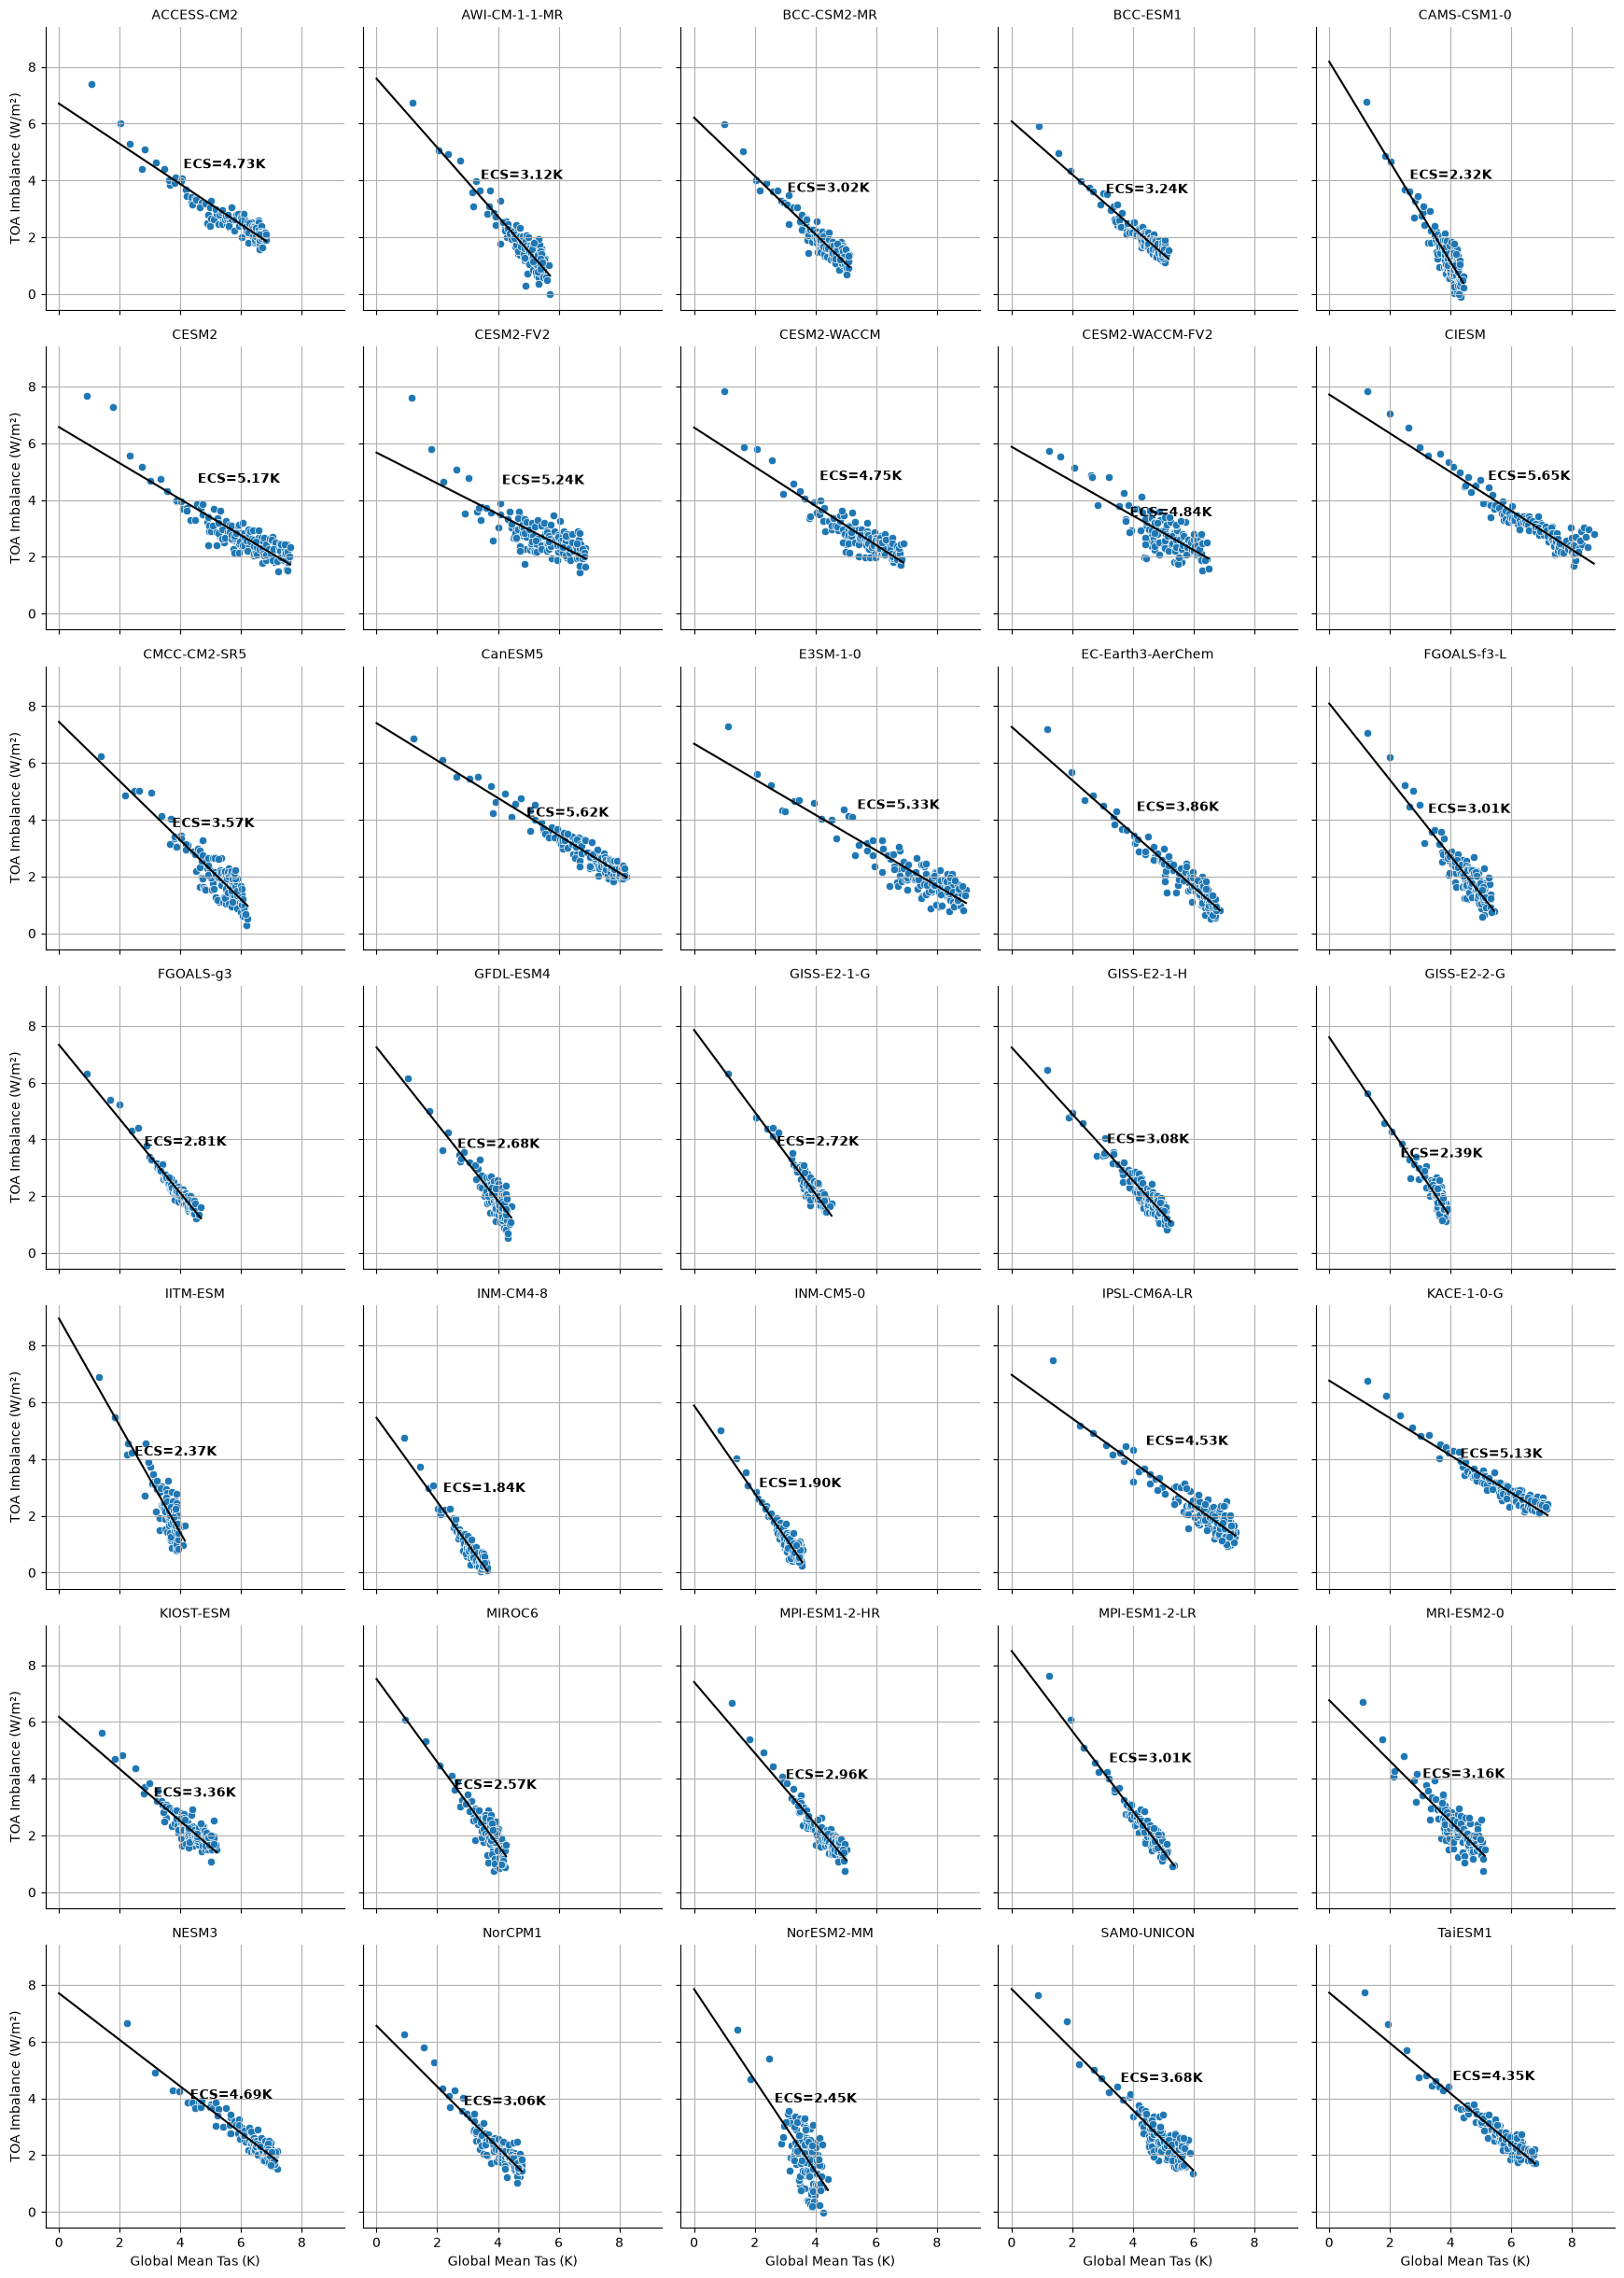

CPU times: user 7.21 s, sys: 373 ms, total: 7.58 s
Wall time: 7.37 s


In [22]:
%%time
# Convert to DataFrame
df = ds_abrupt.to_dataframe().reset_index()

# Drop NaNs
df = df.dropna(subset=['tas', 'imbalance'])

# Set up FacetGrid
g = sns.FacetGrid(df, col="source_id", col_wrap=5, height=3.5)
g.map_dataframe(sns.scatterplot, x="tas", y="imbalance")

# Add Gregory fit line and ECS text
def plot_ecs(data, color, **kwargs):
    x = data['tas'].values
    y = data['imbalance'].values
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    
    if len(x) < 2:
        return  # skip underpopulated panels
    
    a, b = np.polyfit(x, y, 1)
    ecs = -0.5 * b / a
    
    x_line = np.array([0, x.max()])
    y_line = np.polyval([a, b], x_line)
    
    plt.plot(x_line, y_line, 'k')
    plt.text(0.6 * x.max(), 0.6 * y.max(), f'ECS={ecs:2.2f}K', fontsize=10, weight='bold')
    plt.grid(True)

g.map_dataframe(plot_ecs)

# Optional: adjust layout
g.set_titles("{col_name}")
g.set_axis_labels("Global Mean Tas (K)", "TOA Imbalance (W/m²)")
plt.tight_layout()
plt.show()


In [23]:
cluster.close()